In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import displacement as dpm
from libs import fit_model as fm 
from libs import cal_vel as cv

plt.style.use('../libs/my_style.mplstyle')

markers = ["o", "s", "v", "^", '*', 'd']
lines = ["-", "--", "-.", ":", (0, (5, 3, 1, 3, 1, 3))]

In [7]:
scale = 0.11
interval = 2

path1 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20260107/MC03MT10/beads_tracks.csv"
path2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241114/MC03MT4uM/beads_tracks.csv"

track1 = cv.cal(pd.read_csv(path1), scale=scale ,frame_interval=2)
track2 = cv.cal(pd.read_csv(path2), scale=scale ,frame_interval=10)

track2['particle'] += 10000

track = pd.concat([track1, track2])

/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(


(array([741., 576., 500., 412., 436., 389., 412., 403., 463., 502.]),
 array([3.21124351e-04, 3.14386041e-01, 6.28450958e-01, 9.42515874e-01,
        1.25658079e+00, 1.57064571e+00, 1.88471062e+00, 2.19877554e+00,
        2.51284046e+00, 2.82690537e+00, 3.14097029e+00]),
 <BarContainer object of 10 artists>)

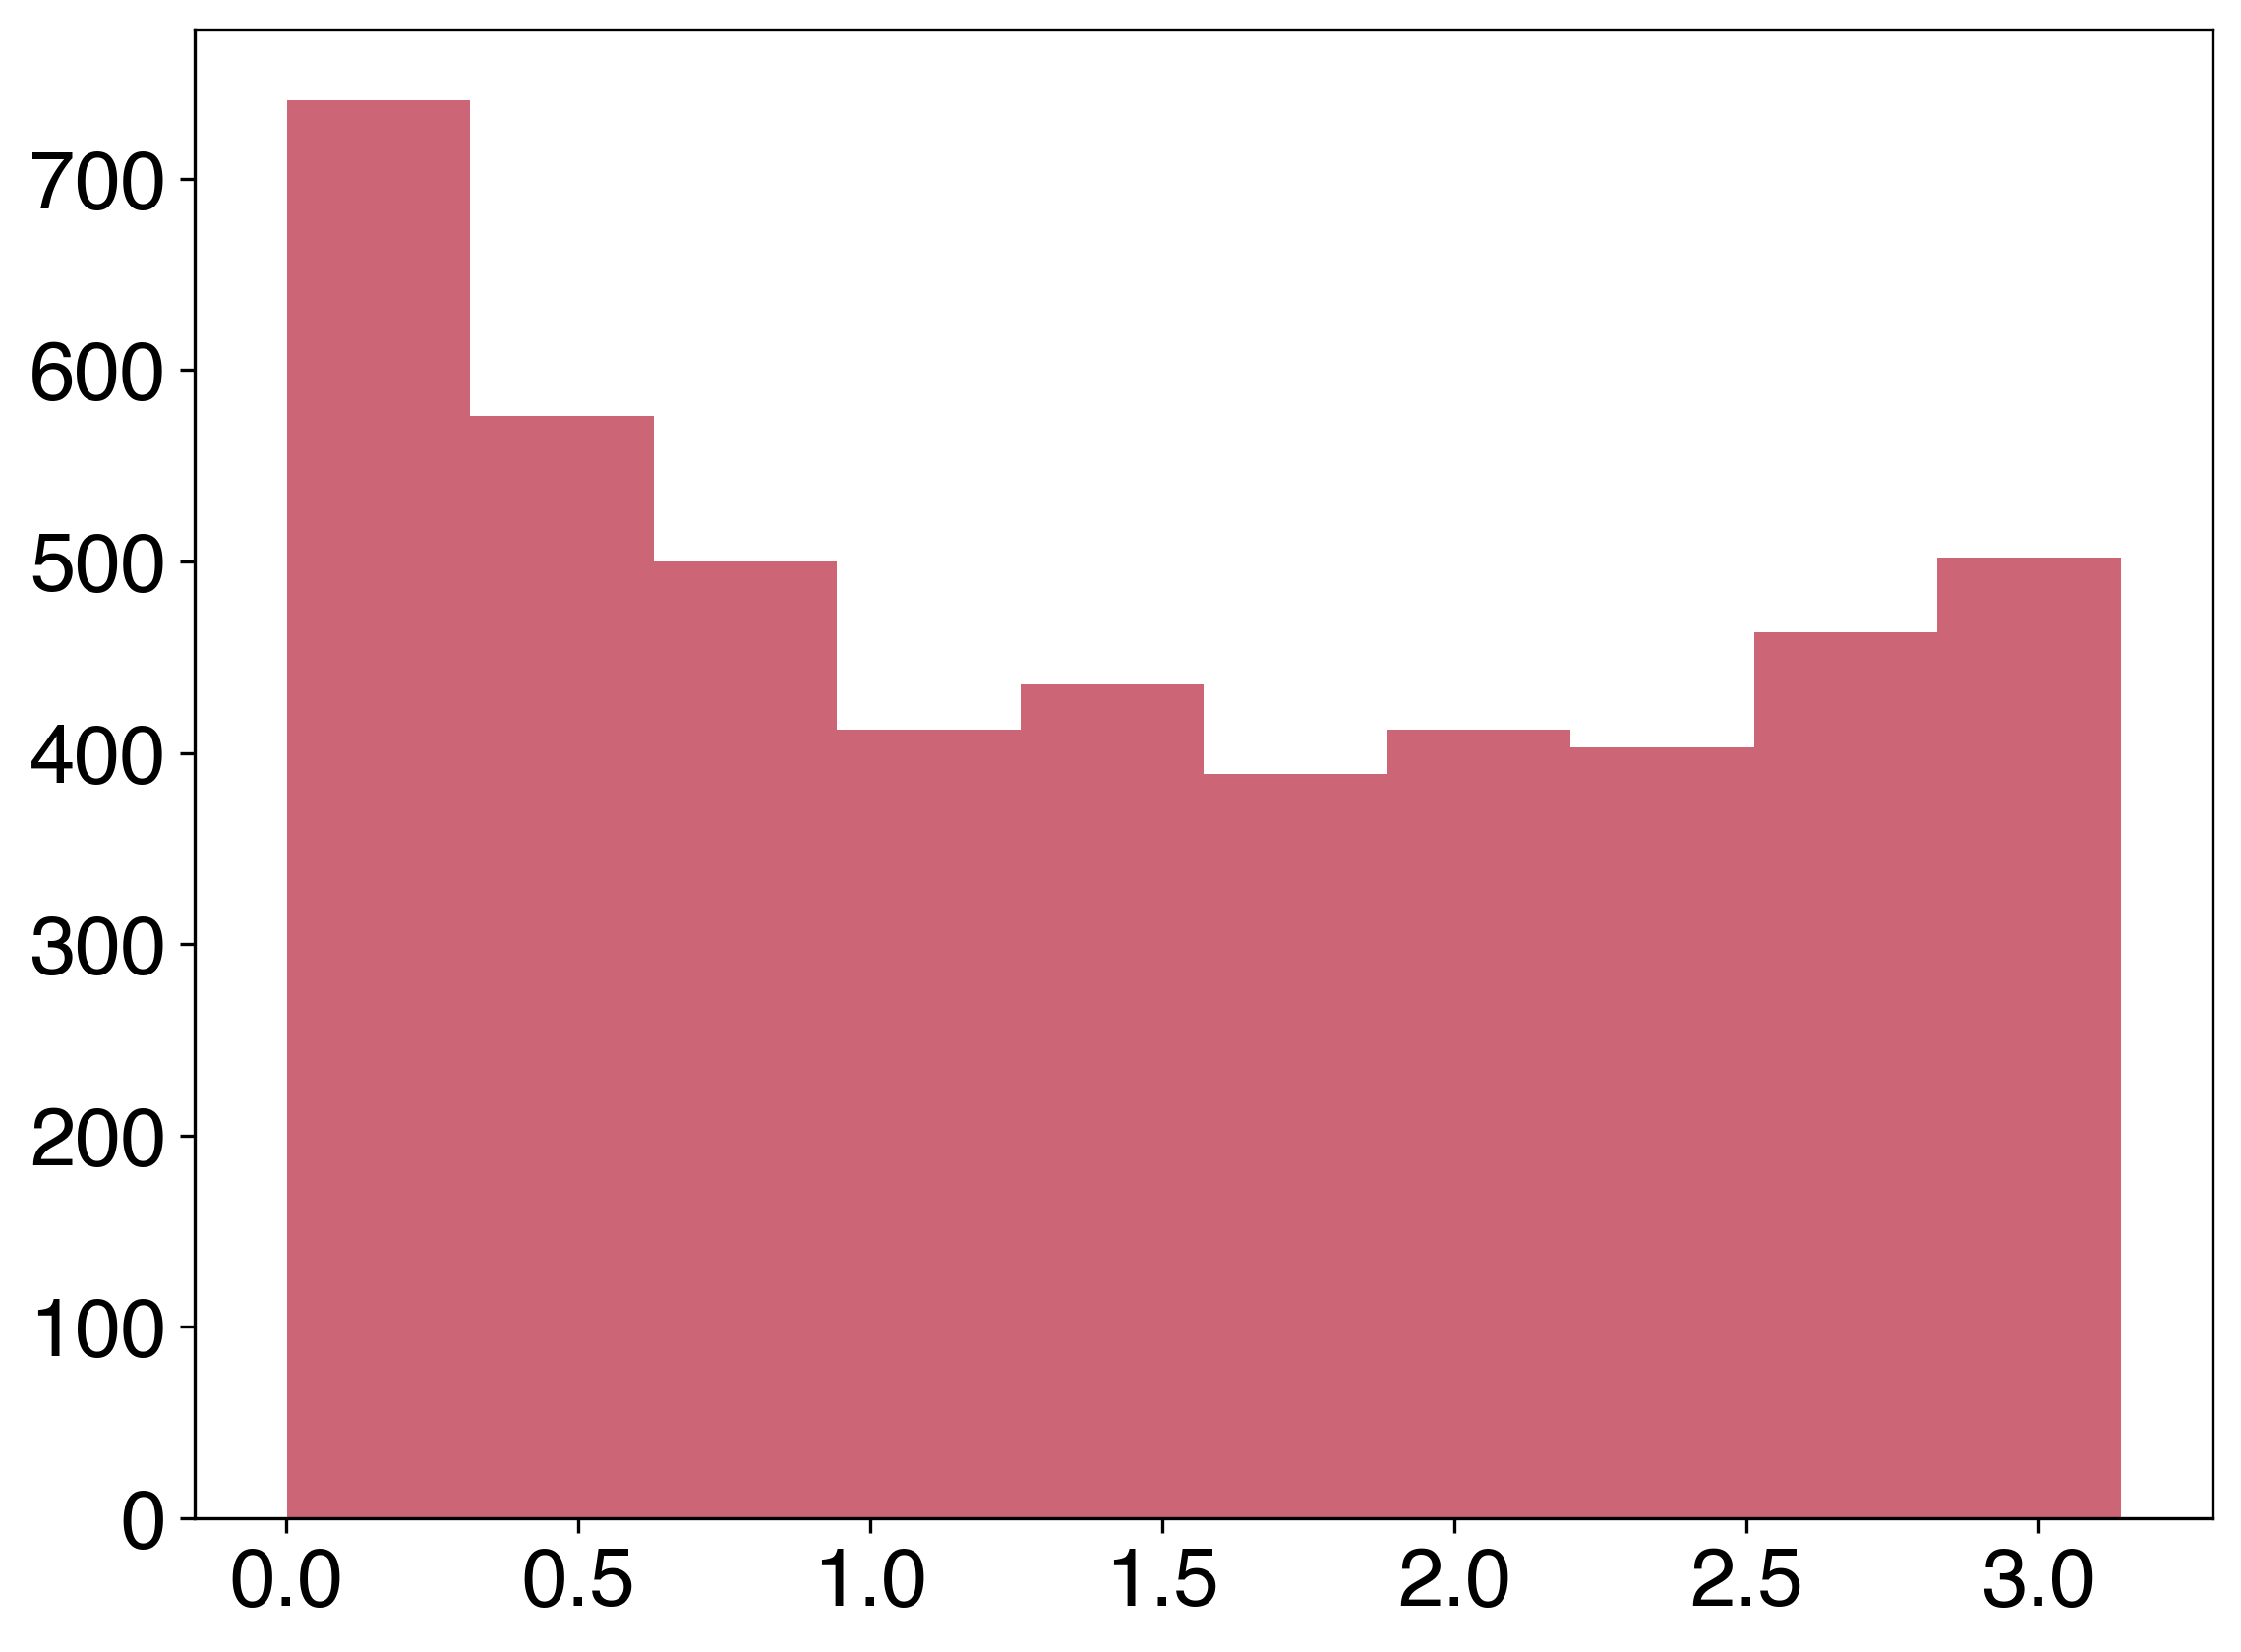

In [8]:
plt.hist(np.abs(track['dtheta'].to_numpy()))

In [9]:
track

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle,v,theta,alpha,t,dtheta,omega
0,1037.185170,583.211911,105469.301961,28.428899,0.067095,36.235294,1965854.0,NaN,0,9,NaN,NaN,NaN,0,NaN,NaN
1,1361.364030,95.326559,115340.235294,24.997879,0.170103,45.898039,1898570.0,NaN,0,11,NaN,NaN,NaN,0,NaN,NaN
2,350.742199,1175.464043,61616.031373,24.744877,0.109314,39.968627,1940617.0,NaN,0,16,NaN,NaN,NaN,0,NaN,NaN
3,1358.772007,94.417694,130651.576471,24.025345,0.218268,55.964706,1815170.0,NaN,1,11,0.151071,-1.908040,NaN,2,NaN,NaN
4,1035.524455,577.535071,115460.443137,26.643146,0.085925,44.666667,1886000.0,NaN,1,9,0.325312,-2.856992,NaN,2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2875,481.987860,2467.860186,211313.819091,26.197638,0.301039,72.869389,1720328.0,NaN,100,10132,0.015190,2.467191,1.920007,1000,-2.047224,-0.204722
2876,557.366825,219.767502,129277.707412,18.975355,0.307871,99.629335,1425326.0,NaN,100,10151,0.254340,-2.500384,-1.039690,1000,0.220206,0.022021
2877,644.141285,2040.633724,158641.601230,20.529499,0.186166,80.691527,1608735.0,NaN,100,10052,0.011493,2.580679,-3.113145,1000,1.962870,0.196287
2878,666.066633,1046.663179,145428.775317,18.882387,0.075422,83.985059,1577322.0,NaN,100,10174,0.019037,-2.358745,2.476410,1000,-0.245532,-0.024553


<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:53: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:53: SyntaxWarning: invalid escape sequence '\D'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_11958/898051712.py:21: SyntaxWarning: invalid escape sequence '\D'
  xlabel='lag time $\Delta t [s]$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_11958/898051712.py:53: SyntaxWarning: invalid escape sequence '\D'
  xlabel='lag time $\Delta t [s]$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_11958/898051712.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  msd_df=pd.concat([msd_df, data])


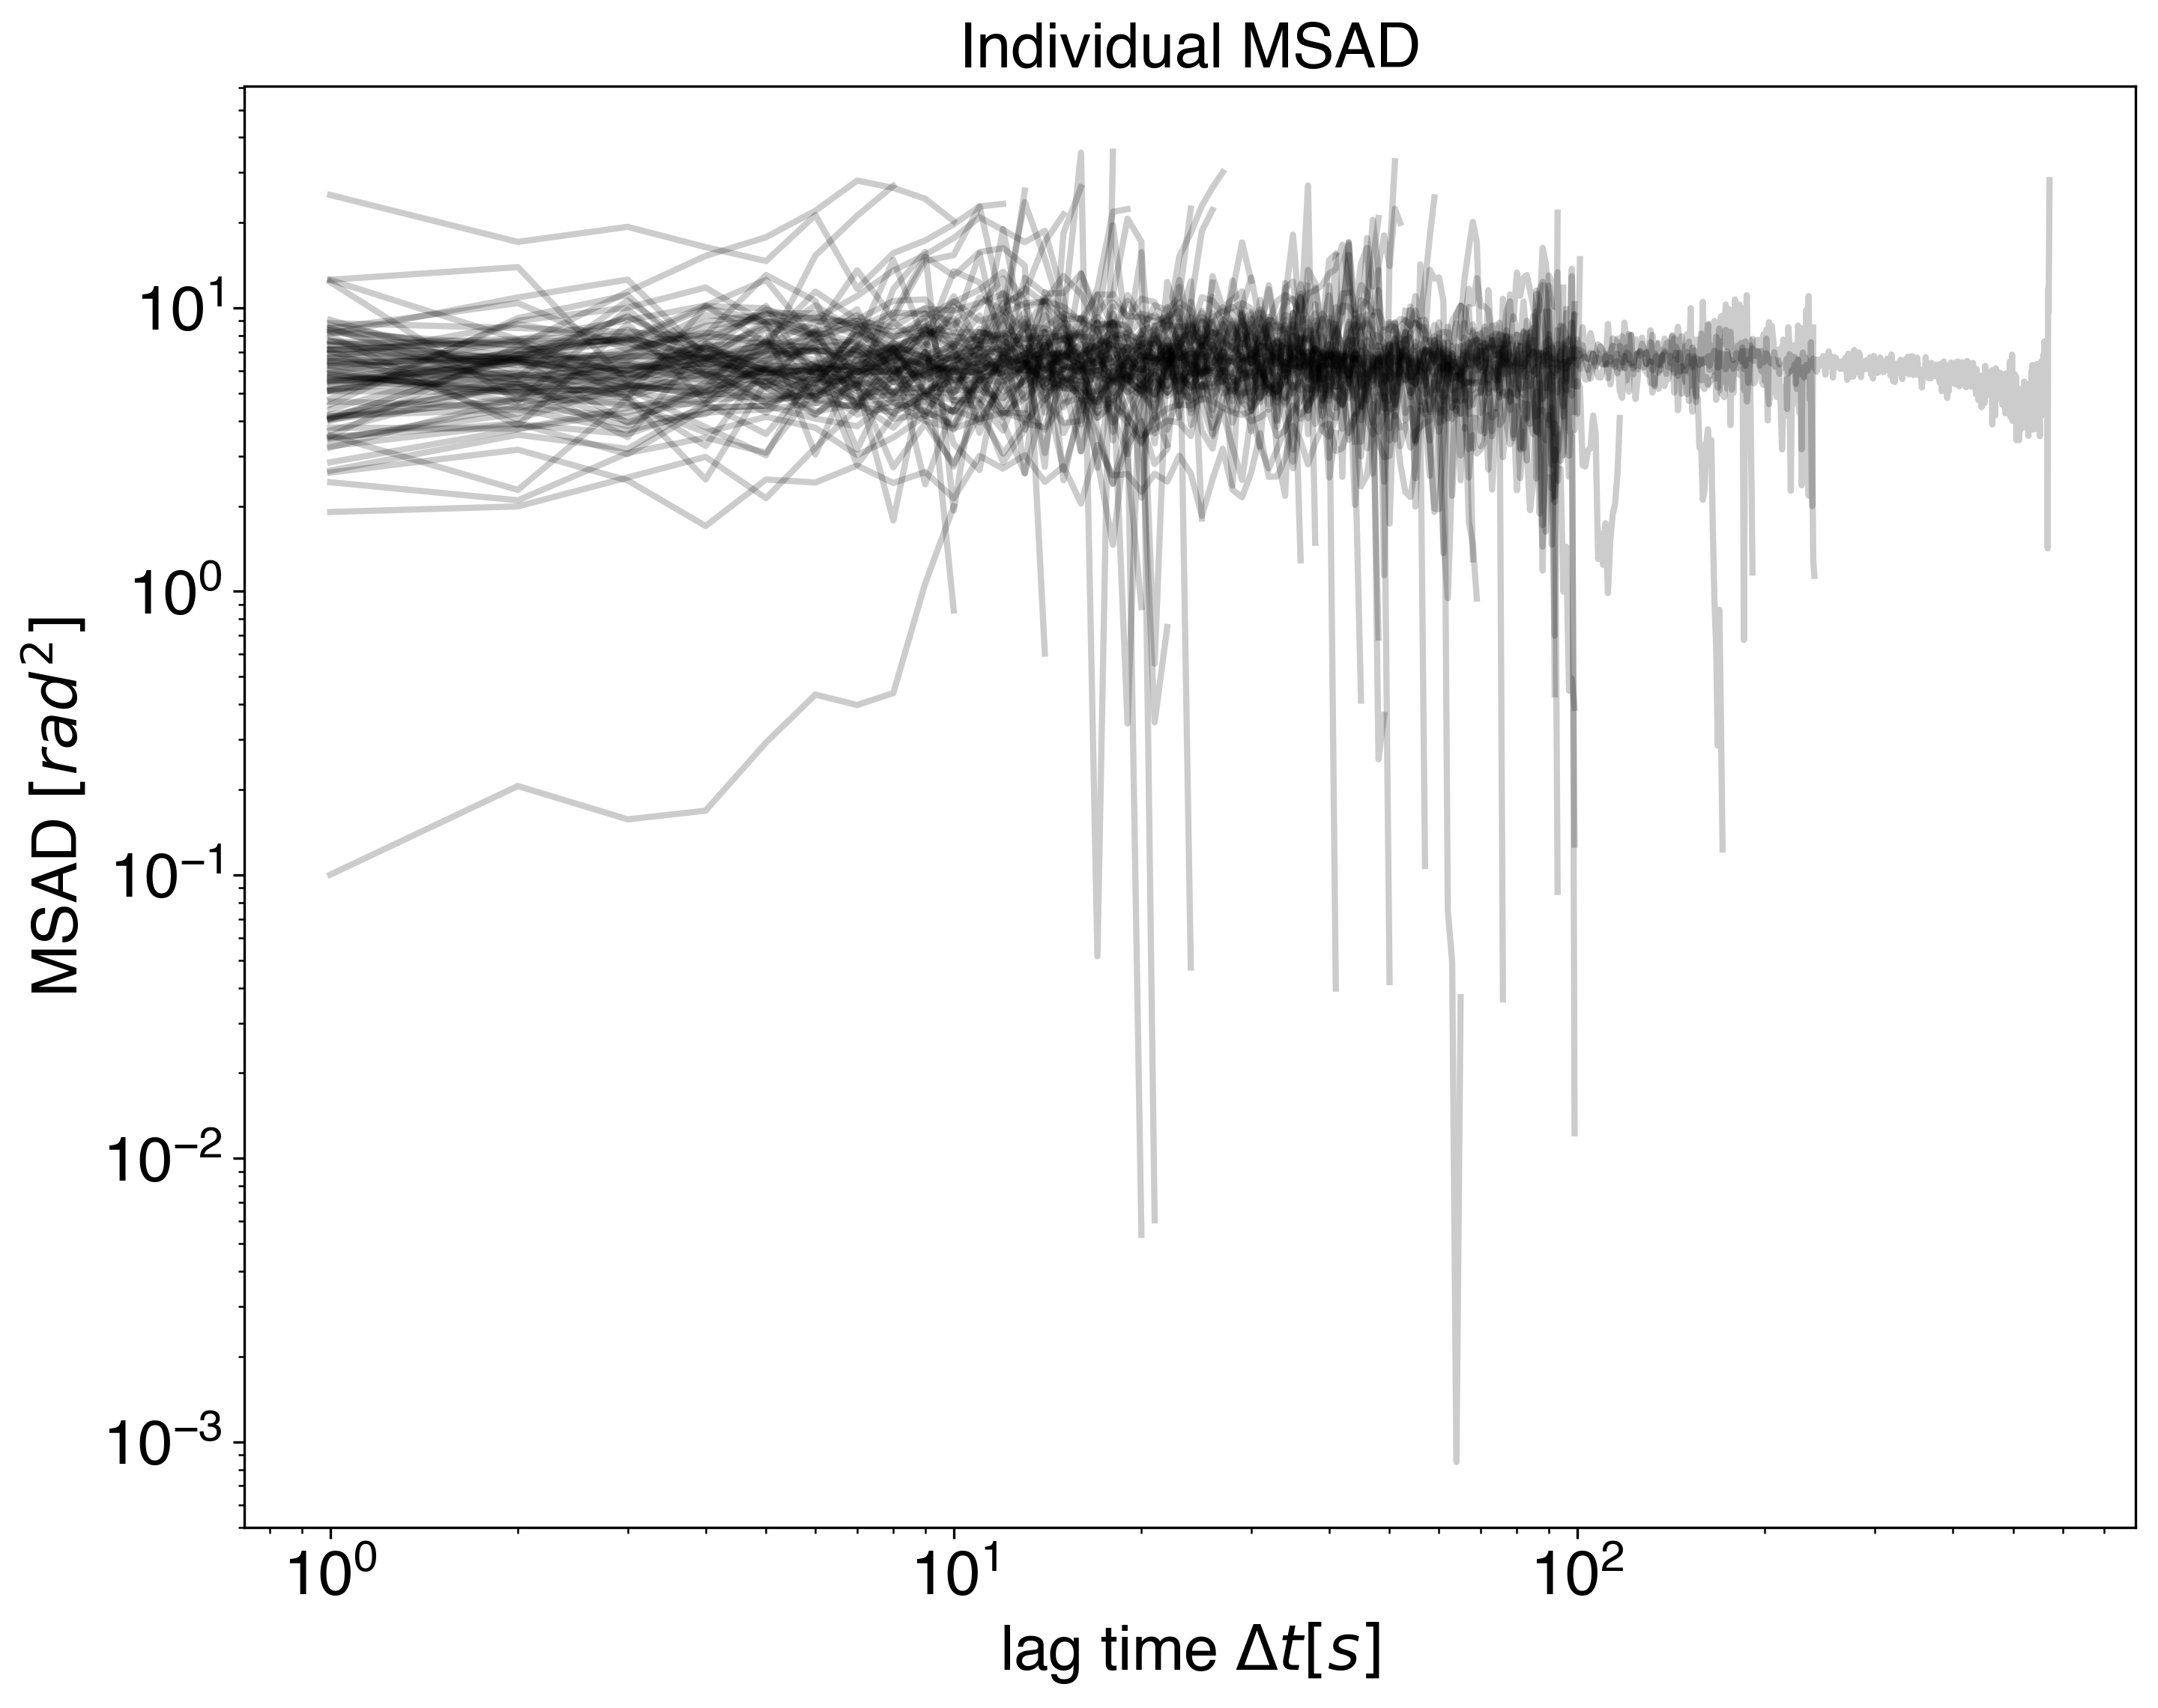

In [18]:
def _calculate_msd(pos):
    num_steps = len(pos)
    msd = []
    for tau in range(1, num_steps):
        displacements = pos[tau:] - pos[:-tau]
        squared_displacements = np.mean(displacements**2)
        msd_tau = np.mean(squared_displacements)
        msd.append(msd_tau)
    
    return np.array(msd)

def imsd(df, time_scale = 1, display=True, figsize=(10,8), title='indivisual MSD'):
    msd_df = pd.DataFrame(columns=['particle', 'lag time', 'MSAD'])


    if display == True:
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set(ylabel='MSAD $[rad^2]$',
        xlabel='lag time $\Delta t [s]$')
        ax.set_title(title)

    for particle_id, group in df.groupby('particle'):
        data = pd.DataFrame()
        group = group.sort_values(by='t')  # フレーム順に並べ替え
        alpha = group['theta'].to_numpy()[1:]
        lag_t = np.arange(1, alpha.shape[0])
        msd=_calculate_msd(alpha)
        data = pd.DataFrame({'particle':particle_id, 'lag time':lag_t, 'MSAD':msd})

        msd_df=pd.concat([msd_df, data])


        if display == True:
            ax.plot(lag_t, msd, color='black', alpha = 0.2)

    return msd_df

def emsd(imsd_list, display=True, figsize=(10,8), title = 'Ensemble MSAD'):
    emsd=imsd_list.groupby('lag time').mean()['MSAD']
    N = len(imsd_list[imsd_list['lag time']==0].index)
    emsd_err = imsd_list.groupby('lag time').std()['MSAD']/np.sqrt(N)
    
    if display == True:
        times = emsd.index
        fig, ax = plt.subplots(figsize=figsize)
        ax.errorbar(times, emsd, yerr= emsd_err, fmt ='o')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set(ylabel='$\\langle \\Delta r^2 \\rangle$ [\u03bcm$^2$]',
        xlabel='lag time $\Delta t [s]$')
        ax.set_title(title)
        ax.grid('True')

    return emsd, emsd_err

imsd_df = imsd(track, time_scale=interval, display=True, title='Individual MSAD')
#emsd_df, emsd_err = emsd(imsd_df, display=True, figsize=(8,6), title='Ensemble MSAD')